<a href="https://colab.research.google.com/github/RenteriaRaul/Doctorado-DCAG/blob/main/notebooks/sustax/02_sustax_validation_obs_vs_era5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Configuración e imports**

In [1]:
from google.colab import drive
import os
import glob
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import probplot

drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación"

SUSTAX_DIR = os.path.join(PROJECT_DIR, "Datos Sustax")
MERGED_DIR = os.path.join(SUSTAX_DIR, "SUSTAX_TOTAL_MERGED")
BYSCEN_TOTAL_FOLDER = os.path.join(MERGED_DIR, "BY_SCENARIO_TOTAL")

CONAGUA_COORDS_XLSX = os.path.join(PROJECT_DIR, "estaciones_conagua_excel/Colima/CoordenadasEstacionesColima.xlsx")
CONAGUA_DATA_FOLDER = os.path.join(PROJECT_DIR, "smn_downloads/Estaciones_Colima")

OBS_TOTAL_OUT_FOLDER = os.path.join(SUSTAX_DIR, "OBS_COMPOSITES_TOTAL")
PHASE_A_OUT_FOLDER = os.path.join(SUSTAX_DIR, "PHASE_A_VALIDATION")

os.makedirs(OBS_TOTAL_OUT_FOLDER, exist_ok=True)
os.makedirs(PHASE_A_OUT_FOLDER, exist_ok=True)

R_KM = 50
MAX_N = 8
IDW_P = 2
MIN_STATIONS_PER_DAY = 1

print("PROJECT_DIR:", PROJECT_DIR)

Mounted at /content/drive
PROJECT_DIR: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación


# **Vecinos Sustax ↔ CONAGUA**

In [2]:
def read_conagua_coords(xlsx_path):
    df = pd.read_excel(xlsx_path)
    df = df.rename(columns={c: str(c).strip().lower() for c in df.columns})

    out = df[["clave", "latitud", "longitud"]].copy()
    out = out.rename(columns={
        "clave": "station_id",
        "latitud": "lat",
        "longitud": "lon"
    })

    out["station_id"] = out["station_id"].astype(str).str.strip()
    out["lat"] = pd.to_numeric(out["lat"], errors="coerce")
    out["lon"] = pd.to_numeric(out["lon"], errors="coerce")
    out = out.dropna(subset=["lat", "lon"])

    return out

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0088
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def build_neighbors_total(total_df, conagua_df, r_km=50, max_n=8):
    rows = []

    con_lat = conagua_df["lat"].to_numpy()
    con_lon = conagua_df["lon"].to_numpy()
    con_id = conagua_df["station_id"].to_numpy()

    for _, s in total_df.iterrows():
        d = haversine_km(s["lat"], s["lon"], con_lat, con_lon)

        mask = d <= r_km
        if mask.sum() == 0:
            continue

        idx = np.argsort(d[mask])[:max_n]
        ids_sel = con_id[mask][idx]
        d_sel = d[mask][idx]

        for sid, dist_km in zip(ids_sel, d_sel):
            rows.append({
                "sustax_total": s["sustax_total"],
                "sustax_lat": s["lat"],
                "sustax_lon": s["lon"],
                "station_id": sid,
                "distance_km": float(dist_km),
                "R_km": r_km,
                "MAX_N": max_n
            })

    neighbors = pd.DataFrame(rows)
    if not neighbors.empty:
        neighbors = neighbors.sort_values(["sustax_total", "distance_km"]).reset_index(drop=True)

    return neighbors

total_summary_path = os.path.join(MERGED_DIR, "BY_SCENARIO_TOTAL", "SUSTAX_TOTAL_BYSCEN_summary.csv")
total_points = pd.read_csv(total_summary_path)

total_points = total_points[["sustax_total", "lat", "lon"]].drop_duplicates().copy()
total_points["lat"] = pd.to_numeric(total_points["lat"], errors="coerce")
total_points["lon"] = pd.to_numeric(total_points["lon"], errors="coerce")
total_points = total_points.dropna(subset=["lat", "lon"])

conagua_df = read_conagua_coords(CONAGUA_COORDS_XLSX)
neighbors_total = build_neighbors_total(
    total_df=total_points,
    conagua_df=conagua_df,
    r_km=R_KM,
    max_n=MAX_N
)

display(neighbors_total.head())

neighbors_csv = os.path.join(MERGED_DIR, "SustaxTotal_CONAGUA_neighbors_R50_N8.csv")
neighbors_total.to_csv(neighbors_csv, index=False)

print("Vecinos guardados en:", neighbors_csv)

,sustax_total,sustax_lat,sustax_lon,station_id,distance_km,R_km,MAX_N
0,Sustax_ Manzanillo_LosReyesTotal,18.9695,-104.0625,6074,4.808588,50,8
1,Sustax_ Manzanillo_LosReyesTotal,18.9695,-104.0625,6001,12.693209,50,8
2,Sustax_ Manzanillo_LosReyesTotal,18.9695,-104.0625,6058,20.915601,50,8
3,Sustax_ Manzanillo_LosReyesTotal,18.9695,-104.0625,6017,24.582937,50,8
4,Sustax_ Manzanillo_LosReyesTotal,18.9695,-104.0625,6070,24.742812,50,8


Vecinos guardados en: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/SUSTAX_TOTAL_MERGED/SustaxTotal_CONAGUA_neighbors_R50_N8.csv


# **OBS compuesta simple e IDW**

In [3]:
def find_station_file(station_id: str, folder: str):
    station_id = str(station_id).strip()
    patterns = [
        os.path.join(folder, f"*{station_id}*.xlsx"),
        os.path.join(folder, f"*{station_id}*.xls"),
        os.path.join(folder, f"*{station_id}*.csv"),
    ]
    matches = []
    for pat in patterns:
        matches.extend(glob.glob(pat))
    if not matches:
        return None
    matches = sorted(matches, key=lambda p: (len(os.path.basename(p)), os.path.basename(p)))
    return matches[0]

def _norm(s):
    s = str(s).strip().lower()
    s = re.sub(r"\s+", "_", s)
    s = s.replace("á","a").replace("é","e").replace("í","i").replace("ó","o").replace("ú","u").replace("ñ","n")
    return s

def detect_date_col(columns):
    cands = {"date","fecha","time","datetime","day","dia"}
    for c in columns:
        if _norm(c) in cands:
            return c
    return None

def detect_pp_col(columns):
    cands = {"pp","precip","precipitacion","precipitation","lluvia","prcp","rain"}
    for c in columns:
        if _norm(c) in cands:
            return c
    for c in columns:
        n = _norm(c)
        if ("precip" in n) or ("pp" == n) or ("lluv" in n) or ("prcp" in n):
            return c
    return None

def read_conagua_station_daily(path):
    ext = os.path.splitext(path)[1].lower()

    if ext in [".xlsx", ".xls"]:
        df = pd.read_excel(path)
    elif ext == ".csv":
        df = pd.read_csv(path)
    else:
        raise ValueError(f"Extensión no soportada: {ext}")

    date_col = detect_date_col(df.columns)
    pp_col = detect_pp_col(df.columns)

    if date_col is None:
        raise ValueError(f"No detecté columna de fecha en {os.path.basename(path)}")
    if pp_col is None:
        raise ValueError(f"No detecté columna de precipitación en {os.path.basename(path)}")

    out = df[[date_col, pp_col]].copy()
    out = out.rename(columns={date_col: "date", pp_col: "pp_mm"})

    out["pp_mm"] = pd.to_numeric(out["pp_mm"], errors="coerce")

    d0 = pd.to_datetime(out["date"], errors="coerce", dayfirst=False)
    d1 = pd.to_datetime(out["date"], errors="coerce", dayfirst=True)
    out["date"] = d1 if d1.notna().sum() > d0.notna().sum() else d0

    out["date"] = out["date"].dt.normalize()

    out = out.dropna(subset=["date"]).sort_values("date")
    out.loc[out["pp_mm"] < 0, "pp_mm"] = np.nan

    out = out.groupby("date", as_index=False)["pp_mm"].mean()

    return out

def build_obs_total(neighbors_df, conagua_folder, idw_p=2, min_stations_per_day=1):
    obs_simple = {}
    obs_idw = {}
    report_rows = []

    for sustax_total, grp in neighbors_df.groupby("sustax_total"):
        grp = grp.copy()
        grp["station_id"] = grp["station_id"].astype(str).str.strip()

        station_meta = []
        station_series = []

        for _, r in grp.iterrows():
            sid = r["station_id"]
            dist = float(r["distance_km"])
            fpath = find_station_file(sid, conagua_folder)

            if fpath is None:
                report_rows.append({
                    "sustax_total": sustax_total,
                    "station_id": sid,
                    "status": "MISSING_FILE",
                    "path": None
                })
                continue

            try:
                df_st = read_conagua_station_daily(fpath)
                df_st = df_st.set_index("date").rename(columns={"pp_mm": f"pp_{sid}"})
                station_series.append(df_st)
                station_meta.append({
                    "station_id": sid,
                    "distance_km": dist,
                    "path": fpath
                })
                report_rows.append({
                    "sustax_total": sustax_total,
                    "station_id": sid,
                    "status": "OK",
                    "path": fpath
                })
            except Exception as e:
                report_rows.append({
                    "sustax_total": sustax_total,
                    "station_id": sid,
                    "status": f"READ_ERROR: {e}",
                    "path": fpath
                })

        if not station_series:
            obs_simple[sustax_total] = pd.DataFrame(columns=["date", "pp_mm"])
            obs_idw[sustax_total] = pd.DataFrame(columns=["date", "pp_mm"])
            continue

        all_dates = pd.Index([])
        for df in station_series:
            all_dates = all_dates.union(df.index)

        aligned = [df.reindex(all_dates) for df in station_series]
        df_all = pd.concat(aligned, axis=1).sort_index()

        n_avail = df_all.notna().sum(axis=1)

        simple = df_all.mean(axis=1, skipna=True)
        simple = simple.where(n_avail >= min_stations_per_day)

        col_sids = [c.replace("pp_", "") for c in df_all.columns]
        dists = []
        for sid in col_sids:
            m = next((x for x in station_meta if x["station_id"] == sid), None)
            dists.append(m["distance_km"] if m else np.nan)
        dists = np.asarray(dists, dtype=float)

        if np.any(np.isnan(dists)):
            idw = simple.copy()
        else:
            vals = df_all.to_numpy(dtype=float)
            idw_vals = np.full(len(df_all), np.nan, dtype=float)

            for i in range(vals.shape[0]):
                row = vals[i, :]
                mask = ~np.isnan(row)

                if mask.sum() >= min_stations_per_day:
                    d = dists[mask]
                    v = row[mask]

                    w = 1.0 / np.maximum(d, 1e-6) ** idw_p
                    w = w / w.sum()

                    idw_vals[i] = np.sum(w * v)

            idw = pd.Series(idw_vals, index=df_all.index)

        out_simple = simple.reset_index()
        out_simple.columns = ["date", "pp_mm"]
        out_simple["date"] = pd.to_datetime(out_simple["date"]).dt.strftime("%Y-%m-%d")

        out_idw = idw.reset_index()
        out_idw.columns = ["date", "pp_mm"]
        out_idw["date"] = pd.to_datetime(out_idw["date"]).dt.strftime("%Y-%m-%d")

        obs_simple[sustax_total] = out_simple
        obs_idw[sustax_total] = out_idw

    report = pd.DataFrame(report_rows)
    return obs_simple, obs_idw, report

obs_simple_total_dict, obs_idw_total_dict, report_total = build_obs_total(
    neighbors_df=neighbors_total,
    conagua_folder=CONAGUA_DATA_FOLDER,
    idw_p=IDW_P,
    min_stations_per_day=MIN_STATIONS_PER_DAY
)

display(report_total["status"].value_counts())

for k, df in obs_simple_total_dict.items():
    out_fp = os.path.join(OBS_TOTAL_OUT_FOLDER, f"OBS_SIMPLE__{k}.csv")
    df.to_csv(out_fp, index=False)

for k, df in obs_idw_total_dict.items():
    out_fp = os.path.join(OBS_TOTAL_OUT_FOLDER, f"OBS_IDW__{k}.csv")
    df.to_csv(out_fp, index=False)

print("OBS TOTAL guardados en:", OBS_TOTAL_OUT_FOLDER)

/tmp/ipykernel_13523/3837799987.py:64: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  d1 = pd.to_datetime(out["date"], errors="coerce", dayfirst=True)
/tmp/ipykernel_13523/3837799987.py:64: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  d1 = pd.to_datetime(out["date"], errors="coerce", dayfirst=True)
/tmp/ipykernel_13523/3837799987.py:64: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  d1 = pd.to_datetime(out["date"], errors="coerce", dayfirst=True)
/tmp/ipykernel_13523/3837799987.py:64: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  d1 = pd.to_datetime(out["date"], errors="coerce", day

,count
status,
OK,86


OBS TOTAL guardados en: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/OBS_COMPOSITES_TOTAL


# **Validación histórica por punto (AMAX, excedencia, QQ, métricas)**

In [4]:
def normalize_date(s):
    d0 = pd.to_datetime(s, errors="coerce", dayfirst=False)
    d1 = pd.to_datetime(s, errors="coerce", dayfirst=True)
    dt = d1 if d1.notna().sum() > d0.notna().sum() else d0
    return dt.dt.normalize()

def pick_precip_col(df):
    meta = {"date","sustax_total","lat","lon"}
    candidates = [c for c in df.columns if c not in meta]

    for c in candidates:
        cl = c.lower()
        if "precip" in cl:
            return c

    raise ValueError("No precip column detected")

obs_files = [f for f in os.listdir(OBS_TOTAL_OUT_FOLDER) if f.startswith("OBS_IDW__")]
points = [f.replace("OBS_IDW__","").replace(".csv","") for f in obs_files]

metrics_rows = []
amax_rows = []

for point in points:
    obs_path = os.path.join(OBS_TOTAL_OUT_FOLDER, f"OBS_IDW__{point}.csv")
    obs = pd.read_csv(obs_path)

    obs["date"] = normalize_date(obs["date"])
    obs = obs.rename(columns={"pp_mm":"obs_mm"})
    obs["year"] = obs["date"].dt.year
    obs["month"] = obs["date"].dt.month

    era5_path = os.path.join(BYSCEN_TOTAL_FOLDER, f"{point}__ERA5__mm.csv")
    if not os.path.exists(era5_path):
        continue

    era5 = pd.read_csv(era5_path)
    era5["date"] = normalize_date(era5["date"])
    precip_col = pick_precip_col(era5)
    era5 = era5.rename(columns={precip_col:"era5_mm"})
    era5["year"] = era5["date"].dt.year
    era5["month"] = era5["date"].dt.month

    df = pd.merge(
        obs[["date","obs_mm"]],
        era5[["date","era5_mm"]],
        on="date",
        how="inner"
    ).dropna()

    if len(df) < 10:
        continue

    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month

    amax = df.groupby("year")[["obs_mm","era5_mm"]].max().reset_index()

    for _, r in amax.iterrows():
        amax_rows.append({
            "point": point,
            "year": r["year"],
            "obs_amax": r["obs_mm"],
            "era5_amax": r["era5_mm"]
        })

    bias = (df["era5_mm"] - df["obs_mm"]).mean()
    rmse = np.sqrt(((df["era5_mm"] - df["obs_mm"])**2).mean())
    corr = df["obs_mm"].corr(df["era5_mm"])

    metrics_rows.append({
        "point": point,
        "bias_mm": bias,
        "rmse_mm": rmse,
        "correlation": corr
    })

    obs_sorted = np.sort(df["obs_mm"].values)[::-1]
    era5_sorted = np.sort(df["era5_mm"].values)[::-1]

    rank_obs = np.arange(1, len(obs_sorted)+1) / len(obs_sorted)
    rank_era5 = np.arange(1, len(era5_sorted)+1) / len(era5_sorted)

    plt.figure(figsize=(7,5))
    plt.plot(obs_sorted, rank_obs, label="OBS")
    plt.plot(era5_sorted, rank_era5, label="ERA5")
    plt.xlabel("Precipitación (mm)")
    plt.ylabel("Probabilidad de excedencia")
    plt.title(f"Exceedance Curve\n{point}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(PHASE_A_OUT_FOLDER, f"{point}_exceedance.png"), dpi=300)
    plt.close()

    plt.figure(figsize=(6,6))
    probplot(df["obs_mm"], dist="norm", plot=plt)
    plt.title(f"QQ Plot OBS\n{point}")
    plt.tight_layout()
    plt.savefig(os.path.join(PHASE_A_OUT_FOLDER, f"{point}_qq_obs.png"), dpi=300)
    plt.close()

    plt.figure(figsize=(6,6))
    probplot(df["era5_mm"], dist="norm", plot=plt)
    plt.title(f"QQ Plot ERA5\n{point}")
    plt.tight_layout()
    plt.savefig(os.path.join(PHASE_A_OUT_FOLDER, f"{point}_qq_era5.png"), dpi=300)
    plt.close()

    plt.figure(figsize=(8,4))
    plt.plot(amax["year"], amax["obs_mm"], label="OBS", marker="o")
    plt.plot(amax["year"], amax["era5_mm"], label="ERA5", marker="o")
    plt.title(f"Annual Maximum Precipitation\n{point}")
    plt.ylabel("mm")
    plt.xlabel("year")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(PHASE_A_OUT_FOLDER, f"{point}_amax_series.png"), dpi=300)
    plt.close()

df_metrics = pd.DataFrame(metrics_rows)
df_amax = pd.DataFrame(amax_rows)

df_metrics.to_csv(os.path.join(PHASE_A_OUT_FOLDER, "metrics_OBS_vs_ERA5.csv"), index=False)
df_amax.to_csv(os.path.join(PHASE_A_OUT_FOLDER, "AMAX_OBS_vs_ERA5.csv"), index=False)

display(df_metrics.head())
print("Fase A por punto completada.")

/tmp/ipykernel_13523/1948350884.py:3: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  d1 = pd.to_datetime(s, errors="coerce", dayfirst=True)
/tmp/ipykernel_13523/1948350884.py:3: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  d1 = pd.to_datetime(s, errors="coerce", dayfirst=True)
/tmp/ipykernel_13523/1948350884.py:3: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  d1 = pd.to_datetime(s, errors="coerce", dayfirst=True)
/tmp/ipykernel_13523/1948350884.py:3: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  d1 = pd.to_datetime(s, errors="coerce", dayfirst=True)


,point,bias_mm,rmse_mm,correlation
0,Sustax_ManzanilloTotal,-0.048824,10.543178,0.508687
1,Sustax_PlayaAzul_ArmeriaTotal,1.007783,10.886954,0.470196
2,Sustax_SeaColimaTotal,0.815631,11.612644,0.518352
3,Sustax_MinatitlanTotal,1.647490,9.785390,0.470101
4,Sustax_MexicoTotal,0.403056,11.394590,0.465138


Fase A por punto completada.


# **Figura global final OBS vs ERA5**

/tmp/ipykernel_13523/1565696267.py:7: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  d1 = pd.to_datetime(s, errors="coerce", dayfirst=True)
/tmp/ipykernel_13523/1565696267.py:7: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  d1 = pd.to_datetime(s, errors="coerce", dayfirst=True)
/tmp/ipykernel_13523/1565696267.py:7: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  d1 = pd.to_datetime(s, errors="coerce", dayfirst=True)
/tmp/ipykernel_13523/1565696267.py:114: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(


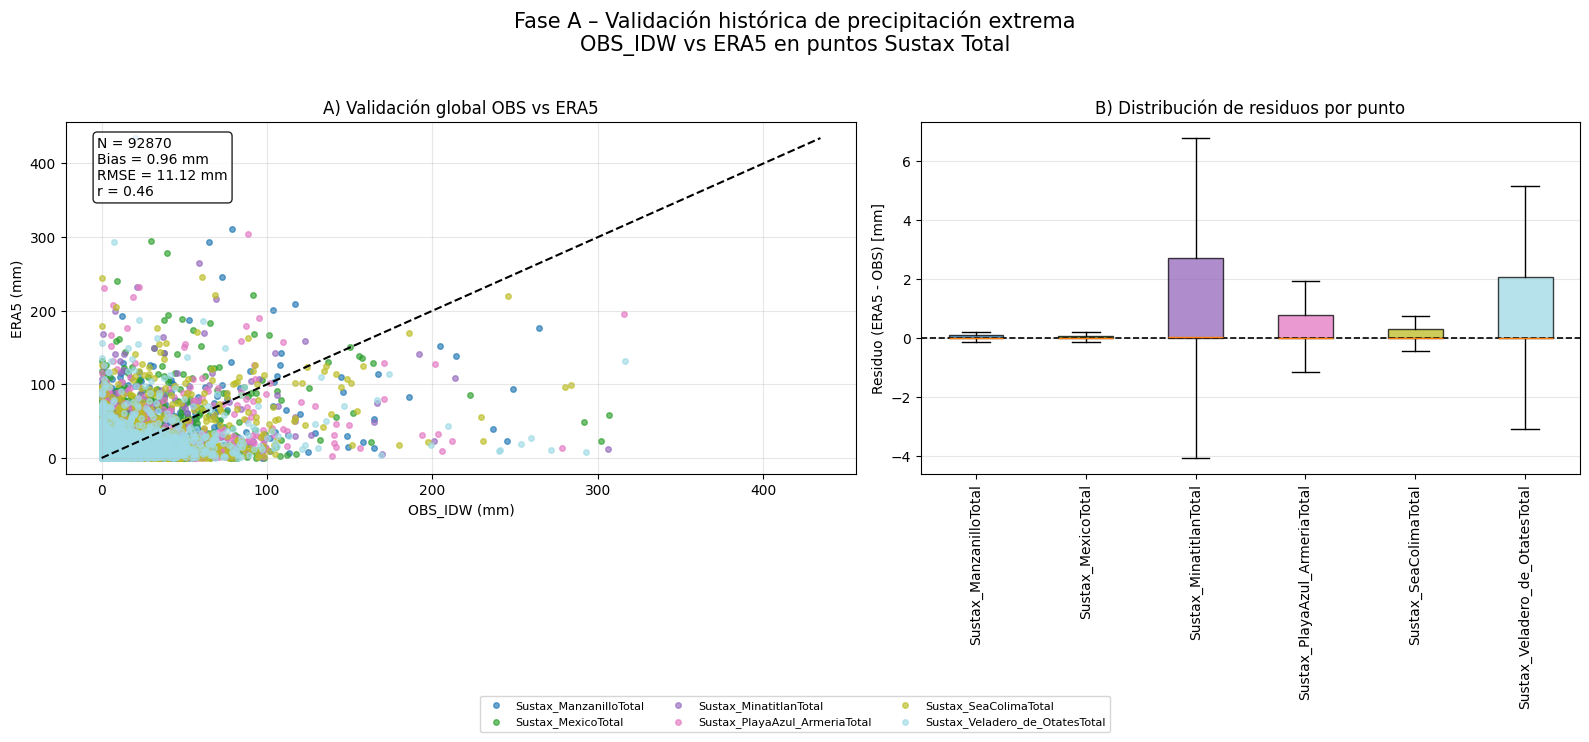

Figura final guardada en:
/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/PHASE_A_VALIDATION/FINAL_validation_OBS_vs_ERA5.png


In [5]:
ERA5_FOLDER = BYSCEN_TOTAL_FOLDER
OBS_FOLDER = OBS_TOTAL_OUT_FOLDER
OUT_FIG = os.path.join(PHASE_A_OUT_FOLDER, "FINAL_validation_OBS_vs_ERA5.png")

def normalize_date(s):
    d0 = pd.to_datetime(s, errors="coerce", dayfirst=False)
    d1 = pd.to_datetime(s, errors="coerce", dayfirst=True)
    dt = d1 if d1.notna().sum() > d0.notna().sum() else d0
    return dt.dt.normalize()

def pick_precip_col(df):
    meta = {"date", "sustax_total", "lat", "lon"}
    candidates = [c for c in df.columns if c not in meta]

    for c in candidates:
        cl = c.lower()
        if ("tp" in cl) and ("precip" in cl):
            return c
    for c in candidates:
        cl = c.lower()
        if ("pr" in cl) and ("precip" in cl):
            return c
    for c in candidates:
        if "precip" in c.lower():
            return c

    if len(candidates) == 1:
        return candidates[0]

    raise ValueError(f"No pude detectar columna de precipitación en: {df.columns.tolist()}")

obs_files = sorted(glob.glob(os.path.join(OBS_FOLDER, "OBS_IDW__*.csv")))
all_rows = []

for obs_fp in obs_files:
    point = os.path.basename(obs_fp).replace("OBS_IDW__", "").replace(".csv", "")

    era5_fp = os.path.join(ERA5_FOLDER, f"{point}__ERA5__mm.csv")
    if not os.path.exists(era5_fp):
        continue

    obs = pd.read_csv(obs_fp)
    obs["date"] = normalize_date(obs["date"])
    obs["obs_mm"] = pd.to_numeric(obs["pp_mm"], errors="coerce")
    obs = obs[["date", "obs_mm"]].dropna()

    era5 = pd.read_csv(era5_fp)
    era5["date"] = normalize_date(era5["date"])
    pp_col = pick_precip_col(era5)
    era5["era5_mm"] = pd.to_numeric(era5[pp_col], errors="coerce")
    era5 = era5[["date", "era5_mm"]].dropna()

    df = pd.merge(obs, era5, on="date", how="inner").dropna()
    if df.empty:
        continue

    df["point"] = point
    df["residual_mm"] = df["era5_mm"] - df["obs_mm"]

    all_rows.append(df)

df_all = pd.concat(all_rows, ignore_index=True)

global_bias = (df_all["era5_mm"] - df_all["obs_mm"]).mean()
global_rmse = np.sqrt(((df_all["era5_mm"] - df_all["obs_mm"]) ** 2).mean())
global_corr = df_all["obs_mm"].corr(df_all["era5_mm"])
n_total = len(df_all)

points = sorted(df_all["point"].unique())
colors = plt.cm.tab20(np.linspace(0, 1, len(points)))
color_map = dict(zip(points, colors))

fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={"width_ratios": [1.2, 1]})

ax = axes[0]
for p in points:
    sub = df_all[df_all["point"] == p]
    ax.scatter(
        sub["obs_mm"],
        sub["era5_mm"],
        s=16,
        alpha=0.65,
        color=color_map[p],
        label=p
    )

xy_max = np.nanmax([df_all["obs_mm"].max(), df_all["era5_mm"].max()])
ax.plot([0, xy_max], [0, xy_max], linestyle="--", color="black", linewidth=1.5)

ax.set_xlabel("OBS_IDW (mm)")
ax.set_ylabel("ERA5 (mm)")
ax.set_title("A) Validación global OBS vs ERA5")

text_metrics = (
    f"N = {n_total}\n"
    f"Bias = {global_bias:.2f} mm\n"
    f"RMSE = {global_rmse:.2f} mm\n"
    f"r = {global_corr:.2f}"
)

ax.text(
    0.04, 0.96, text_metrics,
    transform=ax.transAxes,
    va="top", ha="left",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
)

ax.grid(True, alpha=0.3)

ax2 = axes[1]
data_box = [df_all.loc[df_all["point"] == p, "residual_mm"].dropna().values for p in points]

bp = ax2.boxplot(
    data_box,
    patch_artist=True,
    labels=points,
    vert=True,
    showfliers=False
)

for patch, p in zip(bp["boxes"], points):
    patch.set_facecolor(color_map[p])
    patch.set_alpha(0.75)

ax2.axhline(0, linestyle="--", color="black", linewidth=1.2)
ax2.set_ylabel("Residuo (ERA5 - OBS) [mm]")
ax2.set_title("B) Distribución de residuos por punto")
ax2.tick_params(axis="x", rotation=90)
ax2.grid(True, axis="y", alpha=0.3)

fig.suptitle(
    "Fase A – Validación histórica de precipitación extrema\nOBS_IDW vs ERA5 en puntos Sustax Total",
    fontsize=15,
    y=1.02
)

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=3,
    fontsize=8,
    frameon=True,
    bbox_to_anchor=(0.5, -0.02)
)

plt.tight_layout()
plt.savefig(OUT_FIG, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Figura final guardada en:")
print(OUT_FIG)